<a href="https://colab.research.google.com/github/elsieemorris-ai/Gas-Stove-Pollutant-Reduction/blob/main/CIVE442Tool2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# =========================================
# USER INPUTS
# =========================================

params = {
    # Kitchen / occupancy conditions
    "kitchen_volume_m3": 45.0, # user input here
    "cooking_time_hr": 1.5, # user input here
    "post_cook_time_hr": 1.0, # user input here
    "ach_base_hr": 0.52,   # given assumption

    # Gas stove activity
    "stove_power_kw": 3.5,             # average active gas input power
    "unburned_ch4_fraction": 0.015,    # 1.5% default (within 0.8%–2.3%)
    "nox_ef_ng_per_J": 21.7,           # benchmark provided
    "no2_fraction_of_nox": 0.10,       # assumption: 10% NO2, 90% NO at source

    # Outdoor / background concentrations
    "outdoor_ch4_mg_m3": 1.3,
    "outdoor_no_mg_m3": 0.002,
    "outdoor_no2_mg_m3": 0.020,

    # Alternative A: electrification
    "electrification_fraction": 1.0,   # 1.0 = full replacement

    # Alternative B: hood + extra ventilation
    "hood_capture_efficiency": 0.75,   # 75% capture
    "hood_flow_m3_s": 0.05,            # additional exhaust flow
    "hood_use_fraction": 1.0,          # 1.0 = always used during cooking

    # MCDA weights
    "weight_technical": 0.40,
    "weight_cost": 0.20,
    "weight_health": 0.25,
    "weight_environment": 0.15
}

In [3]:
# =========================================
# MODEL FUNCTIONS
# =========================================

def compute_emission_rates(params):
    """
    Compute stove emissions during cooking.
    Returns emission rates in mg/s for CH4, NO, NO2, and NOx.
    """
    power_J_s = params["stove_power_kw"] * 1000.0

    # Approximate lower heating value of methane
    lhv_ch4_J_per_kg = 50e6

    # CH4 from unburned gas fraction
    ch4_kg_s = (power_J_s / lhv_ch4_J_per_kg) * params["unburned_ch4_fraction"]
    ch4_mg_s = ch4_kg_s * 1e6

    # NOx from benchmark emission factor
    nox_mg_s = power_J_s * params["nox_ef_ng_per_J"] * 1e-6  # ng/J -> mg/s
    no2_mg_s = nox_mg_s * params["no2_fraction_of_nox"]
    no_mg_s = nox_mg_s - no2_mg_s

    return {
        "CH4": ch4_mg_s,
        "NO": no_mg_s,
        "NO2": no2_mg_s,
        "NOx": nox_mg_s
    }


def simulate_single_zone(params, scenario="baseline", dt_s=60):
    """
    Single-zone indoor mass balance model:
    dC/dt = E/V - lambda*(C - Cout)

    scenario:
    - baseline
    - alt_a
    - alt_b
    """
    V = params["kitchen_volume_m3"]
    t_cook_s = params["cooking_time_hr"] * 3600
    t_total_s = (params["cooking_time_hr"] + params["post_cook_time_hr"]) * 3600
    time_s = np.arange(0, t_total_s + dt_s, dt_s)

    base_E = compute_emission_rates(params)

    C_out = {
        "CH4": params["outdoor_ch4_mg_m3"],
        "NO": params["outdoor_no_mg_m3"],
        "NO2": params["outdoor_no2_mg_m3"]
    }

    C = {
        "CH4": np.zeros(len(time_s)),
        "NO": np.zeros(len(time_s)),
        "NO2": np.zeros(len(time_s))
    }

    for p in C:
        C[p][0] = C_out[p]

    ach_base = params["ach_base_hr"]
    lam_base = ach_base / 3600.0

    # Scenario-specific emissions and ventilation during cooking
    if scenario == "baseline":
        E_cook = {
            "CH4": base_E["CH4"],
            "NO": base_E["NO"],
            "NO2": base_E["NO2"]
        }
        lam_cook = lam_base

    elif scenario == "alt_a":
        remaining_gas = 1.0 - params["electrification_fraction"]
        E_cook = {
            "CH4": base_E["CH4"] * remaining_gas,
            "NO": base_E["NO"] * remaining_gas,
            "NO2": base_E["NO2"] * remaining_gas
        }
        lam_cook = lam_base

    elif scenario == "alt_b":
        eff_capture = np.clip(
            params["hood_capture_efficiency"] * params["hood_use_fraction"], 0, 1
        )
        hood_flow = params["hood_flow_m3_s"] * params["hood_use_fraction"]
        added_ach = hood_flow * 3600.0 / V

        E_cook = {
            "CH4": base_E["CH4"] * (1.0 - eff_capture),
            "NO": base_E["NO"] * (1.0 - eff_capture),
            "NO2": base_E["NO2"] * (1.0 - eff_capture)
        }
        lam_cook = (ach_base + added_ach) / 3600.0

    else:
        raise ValueError("scenario must be 'baseline', 'alt_a', or 'alt_b'")

    # Time stepping
    for i in range(1, len(time_s)):
        cooking = time_s[i-1] < t_cook_s

        if cooking:
            E = E_cook
            lam = lam_cook
        else:
            E = {"CH4": 0.0, "NO": 0.0, "NO2": 0.0}
            lam = lam_base

        for p in ["CH4", "NO", "NO2"]:
            dCdt = (E[p] / V) - lam * (C[p][i-1] - C_out[p])
            C[p][i] = max(0, C[p][i-1] + dCdt * dt_s)

    C["NOx"] = C["NO"] + C["NO2"]

    return {
        "time_hr": time_s / 3600.0,
        "concentrations": C,
        "base_emissions_mg_s": base_E,
        "cooking_emissions_mg_s": E_cook,
        "lambda_base_s": lam_base,
        "lambda_cook_s": lam_cook
    }


def summarize_results(result, params):
    """
    Summarize concentration and exposure outputs.
    """
    time_hr = result["time_hr"]
    cooking_mask = time_hr <= params["cooking_time_hr"]

    summary = {}
    for pollutant in ["CH4", "NO", "NO2", "NOx"]:
        c = result["concentrations"][pollutant]
        background = c[0]

        summary[f"{pollutant}_peak_mg_m3"] = np.max(c)
        summary[f"{pollutant}_avg_cooking_mg_m3"] = np.mean(c[cooking_mask])
        summary[f"{pollutant}_avg_total_mg_m3"] = np.mean(c)
        summary[f"{pollutant}_excess_exposure_mg_hr_m3"] = np.trapz(
            np.maximum(c - background, 0), time_hr
        )

    return summary

In [4]:
# =========================================
# RUN SCENARIOS
# =========================================

baseline = simulate_single_zone(params, scenario="baseline")
alt_a = simulate_single_zone(params, scenario="alt_a")
alt_b = simulate_single_zone(params, scenario="alt_b")

results = {
    "Baseline - Gas Stove": baseline,
    "Alternative A - Electrification": alt_a,
    "Alternative B - Hood + Ventilation": alt_b
}

summary_df = pd.DataFrame({
    name: summarize_results(res, params) for name, res in results.items()
}).T

print("Summary table:")
display(summary_df.round(4))

Summary table:


/tmp/ipykernel_41219/767691535.py:144: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  summary[f"{pollutant}_excess_exposure_mg_hr_m3"] = np.trapz(


,CH4_peak_mg_m3,CH4_avg_cooking_mg_m3,CH4_avg_total_mg_m3,CH4_excess_exposure_mg_hr_m3,NO_peak_mg_m3,NO_avg_cooking_mg_m3,NO_avg_total_mg_m3,NO_excess_exposure_mg_hr_m3,NO2_peak_mg_m3,NO2_avg_cooking_mg_m3,NO2_avg_total_mg_m3,NO2_excess_exposure_mg_hr_m3,NOx_peak_mg_m3,NOx_avg_cooking_mg_m3,NOx_avg_total_mg_m3,NOx_excess_exposure_mg_hr_m3
Baseline - Gas Stove,89.0396,50.7770,58.1565,142.6551,5.7138,3.2230,3.7034,9.2868,0.6546,0.3779,0.4313,1.0319,6.3685,3.6008,4.1346,10.3187
Alternative A - Electrification,1.3000,1.3000,1.3000,0.0000,0.0020,0.0020,0.0020,0.0000,0.0200,0.0200,0.0200,0.0000,0.0220,0.0220,0.0220,0.0000
Alternative B - Hood + Ventilation,5.9420,5.2688,5.1224,9.5967,0.3042,0.2604,0.2508,0.6247,0.0536,0.0487,0.0476,0.0694,0.3578,0.3091,0.2985,0.6942


In [5]:
# =========================================
# EMISSION LOAD COMPARISON
# =========================================

base_E = baseline["base_emissions_mg_s"]
cook_seconds = params["cooking_time_hr"] * 3600

effective_capture = np.clip(
    params["hood_capture_efficiency"] * params["hood_use_fraction"], 0, 1
)

emission_table = pd.DataFrame({
    "Baseline - Gas Stove": {
        "CH4 emitted indoors during cooking (mg/s)": base_E["CH4"],
        "NO emitted indoors during cooking (mg/s)": base_E["NO"],
        "NO2 emitted indoors during cooking (mg/s)": base_E["NO2"],
        "NOx emitted indoors during cooking (mg/s)": base_E["NOx"],
        "CH4 total emitted indoors during cooking (mg)": base_E["CH4"] * cook_seconds,
        "NOx total emitted indoors during cooking (mg)": base_E["NOx"] * cook_seconds
    },
    "Alternative A - Electrification": {
        "CH4 emitted indoors during cooking (mg/s)": base_E["CH4"] * (1 - params["electrification_fraction"]),
        "NO emitted indoors during cooking (mg/s)": base_E["NO"] * (1 - params["electrification_fraction"]),
        "NO2 emitted indoors during cooking (mg/s)": base_E["NO2"] * (1 - params["electrification_fraction"]),
        "NOx emitted indoors during cooking (mg/s)": base_E["NOx"] * (1 - params["electrification_fraction"]),
        "CH4 total emitted indoors during cooking (mg)": base_E["CH4"] * (1 - params["electrification_fraction"]) * cook_seconds,
        "NOx total emitted indoors during cooking (mg)": base_E["NOx"] * (1 - params["electrification_fraction"]) * cook_seconds
    },
    "Alternative B - Hood + Ventilation": {
        "CH4 emitted indoors during cooking (mg/s)": base_E["CH4"] * (1 - effective_capture),
        "NO emitted indoors during cooking (mg/s)": base_E["NO"] * (1 - effective_capture),
        "NO2 emitted indoors during cooking (mg/s)": base_E["NO2"] * (1 - effective_capture),
        "NOx emitted indoors during cooking (mg/s)": base_E["NOx"] * (1 - effective_capture),
        "CH4 total emitted indoors during cooking (mg)": base_E["CH4"] * (1 - effective_capture) * cook_seconds,
        "NOx total emitted indoors during cooking (mg)": base_E["NOx"] * (1 - effective_capture) * cook_seconds
    }
}).T

print("Indoor emission comparison:")
display(emission_table.round(4))

Indoor emission comparison:


,CH4 emitted indoors during cooking (mg/s),NO emitted indoors during cooking (mg/s),NO2 emitted indoors during cooking (mg/s),NOx emitted indoors during cooking (mg/s),CH4 total emitted indoors during cooking (mg),NOx total emitted indoors during cooking (mg)
Baseline - Gas Stove,1.0500,0.0684,0.0076,0.0759,5670.0,410.1300
Alternative A - Electrification,0.0000,0.0000,0.0000,0.0000,0.0,0.0000
Alternative B - Hood + Ventilation,0.2625,0.0171,0.0019,0.0190,1417.5,102.5325


In [6]:
# =========================================
# TECHNICAL EFFECTIVENESS
# =========================================

baseline_row = summary_df.loc["Baseline - Gas Stove"]

technical_rows = []
for alt in ["Alternative A - Electrification", "Alternative B - Hood + Ventilation"]:
    row = summary_df.loc[alt]

    ch4_red = 100 * (baseline_row["CH4_avg_cooking_mg_m3"] - row["CH4_avg_cooking_mg_m3"]) / baseline_row["CH4_avg_cooking_mg_m3"]
    no_red = 100 * (baseline_row["NO_avg_cooking_mg_m3"] - row["NO_avg_cooking_mg_m3"]) / baseline_row["NO_avg_cooking_mg_m3"]
    no2_red = 100 * (baseline_row["NO2_avg_cooking_mg_m3"] - row["NO2_avg_cooking_mg_m3"]) / baseline_row["NO2_avg_cooking_mg_m3"]
    nox_red = 100 * (baseline_row["NOx_avg_cooking_mg_m3"] - row["NOx_avg_cooking_mg_m3"]) / baseline_row["NOx_avg_cooking_mg_m3"]

    exposure_red = 100 * (
        baseline_row["NOx_excess_exposure_mg_hr_m3"] - row["NOx_excess_exposure_mg_hr_m3"]
    ) / baseline_row["NOx_excess_exposure_mg_hr_m3"]

    technical_rows.append({
        "Scenario": alt,
        "CH4 avg cooking concentration reduction (%)": ch4_red,
        "NO reduction (%)": no_red,
        "NO2 reduction (%)": no2_red,
        "NOx reduction (%)": nox_red,
        "NOx excess exposure reduction (%)": exposure_red,
        "Combined technical score basis (%)": 0.5 * (ch4_red + nox_red)
    })

technical_df = pd.DataFrame(technical_rows).set_index("Scenario")

print("Technical effectiveness comparison:")
display(technical_df.round(2))

Technical effectiveness comparison:


,CH4 avg cooking concentration reduction (%),NO reduction (%),NO2 reduction (%),NOx reduction (%),NOx excess exposure reduction (%),Combined technical score basis (%)
Scenario,,,,,,
Alternative A - Electrification,97.44,99.94,94.71,99.39,100.00,98.41
Alternative B - Hood + Ventilation,89.62,91.92,87.11,91.42,93.27,90.52


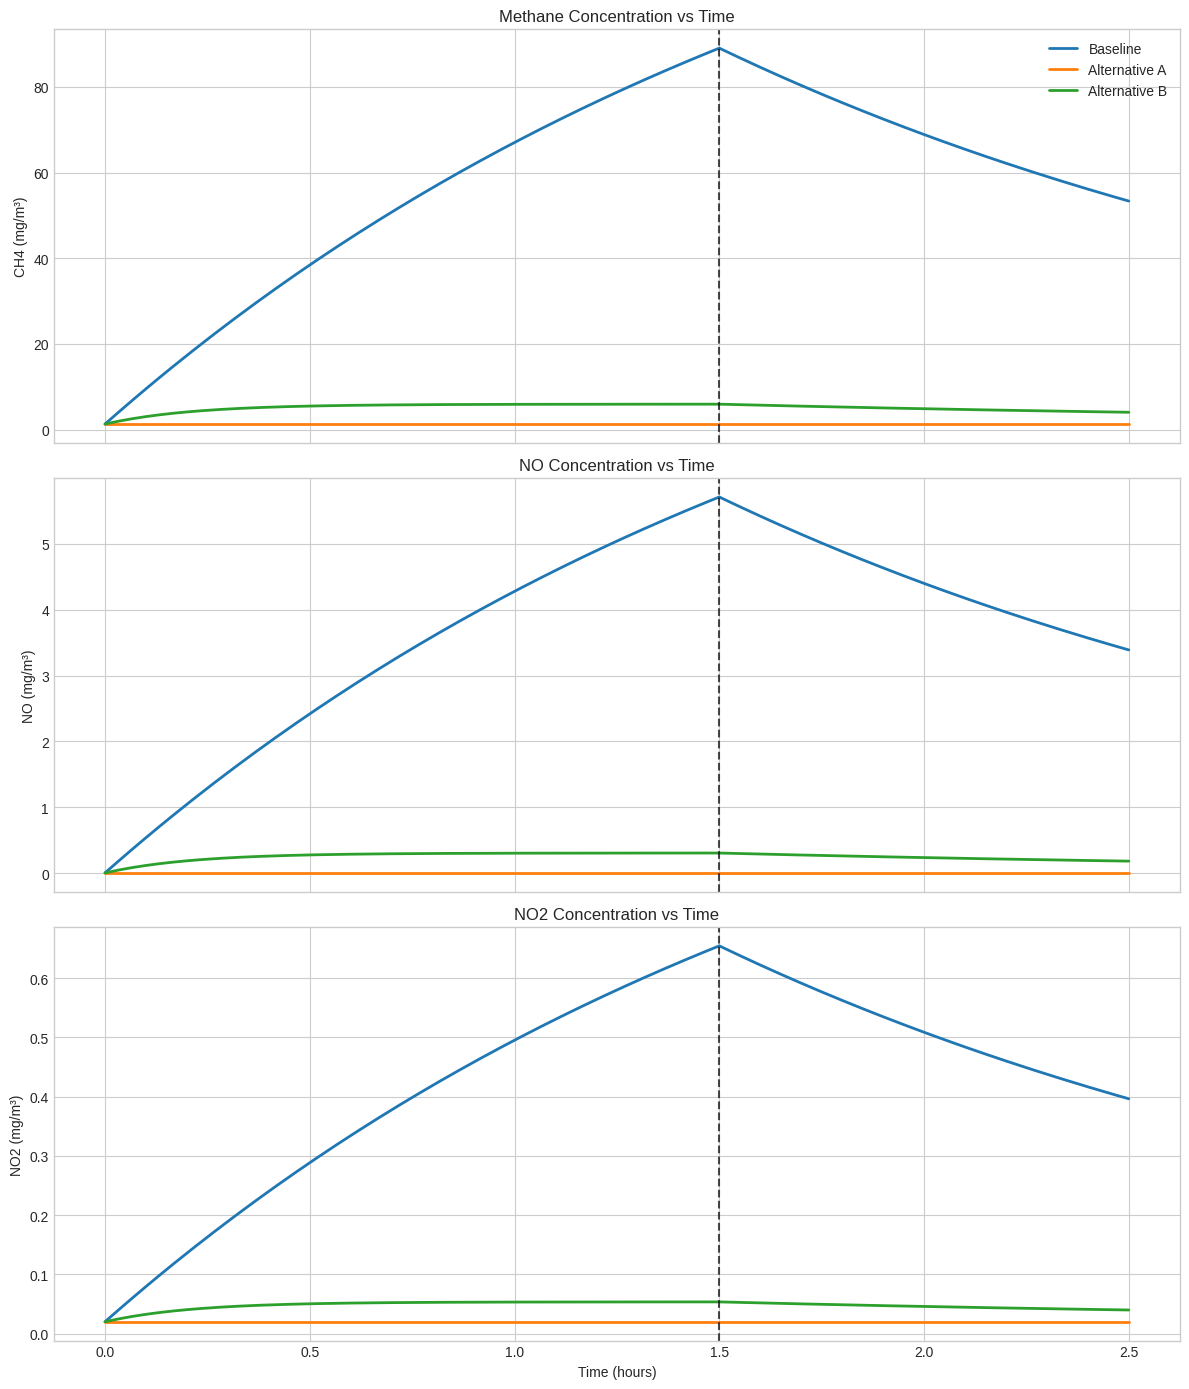

In [7]:
# =========================================
# PLOTS
# =========================================

time_hr = baseline["time_hr"]

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# CH4
axes[0].plot(time_hr, baseline["concentrations"]["CH4"], label="Baseline", linewidth=2)
axes[0].plot(time_hr, alt_a["concentrations"]["CH4"], label="Alternative A", linewidth=2)
axes[0].plot(time_hr, alt_b["concentrations"]["CH4"], label="Alternative B", linewidth=2)
axes[0].axvline(params["cooking_time_hr"], linestyle="--", color="black", alpha=0.7)
axes[0].set_ylabel("CH4 (mg/m³)")
axes[0].set_title("Methane Concentration vs Time")
axes[0].legend()

# NO
axes[1].plot(time_hr, baseline["concentrations"]["NO"], label="Baseline", linewidth=2)
axes[1].plot(time_hr, alt_a["concentrations"]["NO"], label="Alternative A", linewidth=2)
axes[1].plot(time_hr, alt_b["concentrations"]["NO"], label="Alternative B", linewidth=2)
axes[1].axvline(params["cooking_time_hr"], linestyle="--", color="black", alpha=0.7)
axes[1].set_ylabel("NO (mg/m³)")
axes[1].set_title("NO Concentration vs Time")

# NO2
axes[2].plot(time_hr, baseline["concentrations"]["NO2"], label="Baseline", linewidth=2)
axes[2].plot(time_hr, alt_a["concentrations"]["NO2"], label="Alternative A", linewidth=2)
axes[2].plot(time_hr, alt_b["concentrations"]["NO2"], label="Alternative B", linewidth=2)
axes[2].axvline(params["cooking_time_hr"], linestyle="--", color="black", alpha=0.7)
axes[2].set_ylabel("NO2 (mg/m³)")
axes[2].set_xlabel("Time (hours)")
axes[2].set_title("NO2 Concentration vs Time")

plt.tight_layout()
plt.show()

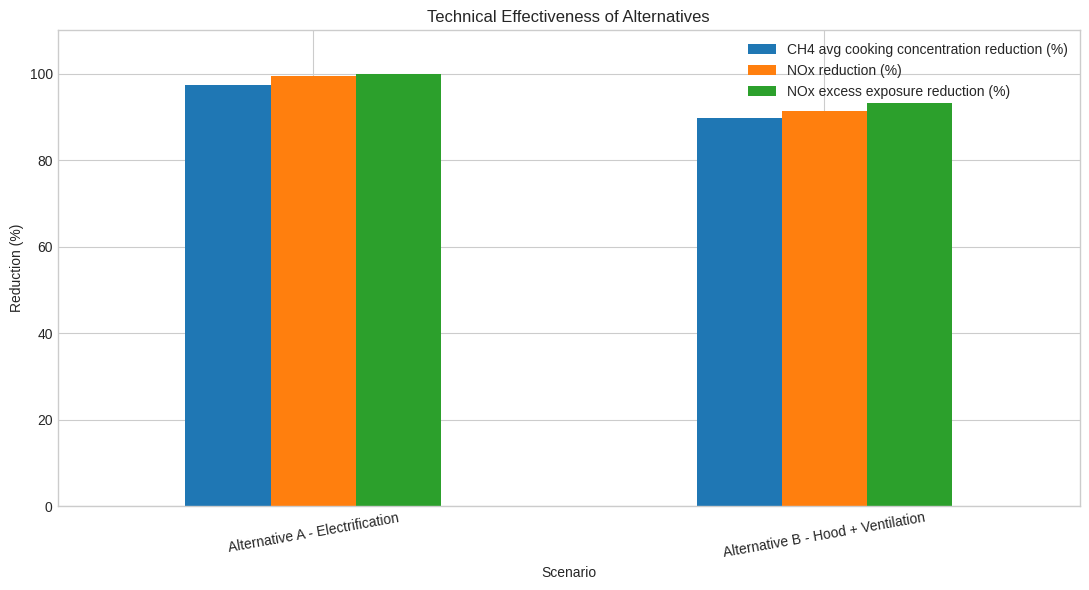

In [8]:
# =========================================
# BAR CHART OF REDUCTIONS
# =========================================

plot_df = technical_df[[
    "CH4 avg cooking concentration reduction (%)",
    "NOx reduction (%)",
    "NOx excess exposure reduction (%)"
]]

plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Technical Effectiveness of Alternatives")
plt.ylabel("Reduction (%)")
plt.xticks(rotation=10)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [9]:
# =========================================
# MCDA
# =========================================

weights = pd.Series({
    "Technical Effectiveness": params["weight_technical"],
    "Cost & Practicality": params["weight_cost"],
    "Public Health & Safety": params["weight_health"],
    "Environmental Considerations": params["weight_environment"]
})

# Convert technical performance to 0-5 score
technical_scores = {}
for alt in technical_df.index:
    performance = technical_df.loc[alt, "Combined technical score basis (%)"]
    technical_scores[alt] = min(5.0, max(0.0, performance / 20.0))

# Editable qualitative/semi-quantitative scores
qualitative_scores = pd.DataFrame({
    "Alternative A - Electrification": {
        "Cost & Practicality": 2.0,
        "Public Health & Safety": 5.0,
        "Environmental Considerations": 4.0
    },
    "Alternative B - Hood + Ventilation": {
        "Cost & Practicality": 4.0,
        "Public Health & Safety": 4.0,
        "Environmental Considerations": 3.0
    }
})

mcda_scores = pd.DataFrame(index=weights.index, columns=qualitative_scores.columns)
mcda_scores.loc["Technical Effectiveness"] = pd.Series(technical_scores)
mcda_scores.loc["Cost & Practicality"] = qualitative_scores.loc["Cost & Practicality"]
mcda_scores.loc["Public Health & Safety"] = qualitative_scores.loc["Public Health & Safety"]
mcda_scores.loc["Environmental Considerations"] = qualitative_scores.loc["Environmental Considerations"]
mcda_scores = mcda_scores.astype(float)

weighted_scores = mcda_scores.mul(weights, axis=0)
mcda_total = weighted_scores.sum(axis=0).sort_values(ascending=False)

print("MCDA raw scores (0 to 5):")
display(mcda_scores.round(2))

print("Weighted MCDA scores:")
display(weighted_scores.round(2))

print("Final MCDA ranking:")
display(pd.DataFrame({"Total Weighted Score": mcda_total}).round(2))

MCDA raw scores (0 to 5):


,Alternative A - Electrification,Alternative B - Hood + Ventilation
Technical Effectiveness,4.92,4.53
Cost & Practicality,2.00,4.00
Public Health & Safety,5.00,4.00
Environmental Considerations,4.00,3.00


Weighted MCDA scores:


,Alternative A - Electrification,Alternative B - Hood + Ventilation
Technical Effectiveness,1.97,1.81
Cost & Practicality,0.40,0.80
Public Health & Safety,1.25,1.00
Environmental Considerations,0.60,0.45


Final MCDA ranking:


,Total Weighted Score
Alternative A - Electrification,4.22
Alternative B - Hood + Ventilation,4.06


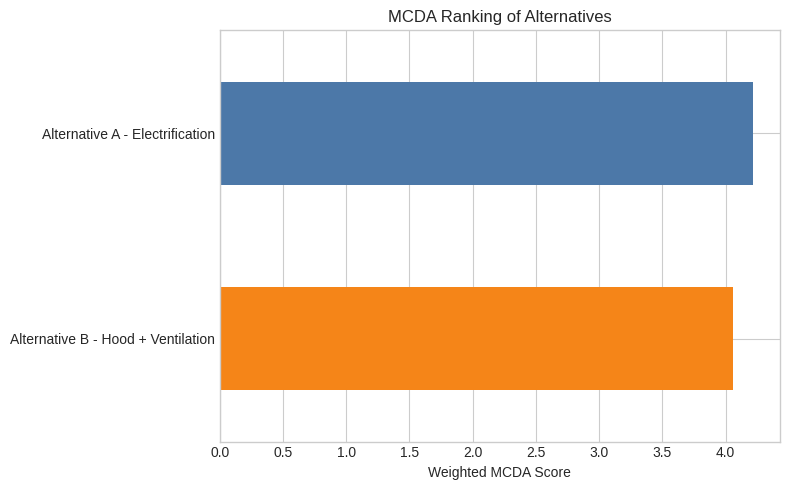

In [10]:
# =========================================
# MCDA PLOT
# =========================================

mcda_total.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    color=["#F58518", "#4C78A8"]
)
plt.xlabel("Weighted MCDA Score")
plt.title("MCDA Ranking of Alternatives")
plt.tight_layout()
plt.show()

In [11]:
# =========================================
# MCDA INTERPRETATION NOTES
# =========================================

mcda_notes = pd.DataFrame({
    "Alternative A - Electrification": {
        "Cost & Practicality": "Higher upfront cost; may require appliance replacement and electrical upgrades.",
        "Public Health & Safety": "Best reduction in indoor CH4 and NOx exposure for cooks and nearby occupants.",
        "Environmental Considerations": "Eliminates indoor combustion, but some impacts shift upstream to electricity generation."
    },
    "Alternative B - Hood + Ventilation": {
        "Cost & Practicality": "More practical retrofit; lower cost, but depends on installation and user behavior.",
        "Public Health & Safety": "Improves exposure only when hood is used properly and capture efficiency remains high.",
        "Environmental Considerations": "Still uses gas; extra fan energy is required and pollutants are vented outdoors."
    }
})

display(mcda_notes)

,Alternative A - Electrification,Alternative B - Hood + Ventilation
Cost & Practicality,Higher upfront cost; may require appliance rep...,"More practical retrofit; lower cost, but depen..."
Public Health & Safety,Best reduction in indoor CH4 and NOx exposure ...,Improves exposure only when hood is used prope...
Environmental Considerations,"Eliminates indoor combustion, but some impacts...",Still uses gas; extra fan energy is required a...


/tmp/ipykernel_41219/767691535.py:144: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  summary[f"{pollutant}_excess_exposure_mg_hr_m3"] = np.trapz(


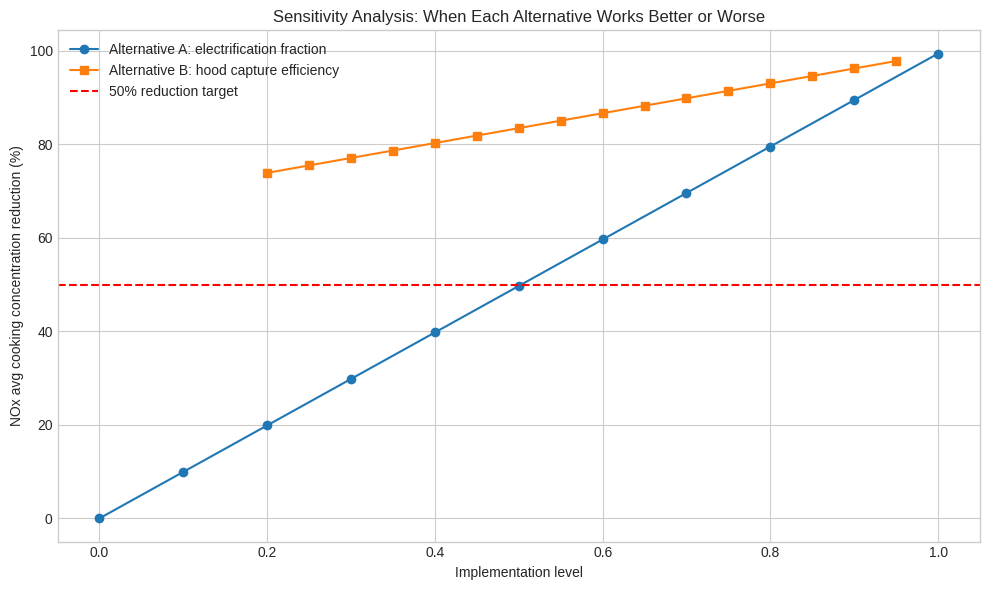

Alternative A reaches at least 50% NOx reduction at electrification fraction ≈ 0.60 or higher.
Alternative B reaches at least 50% NOx reduction at hood capture efficiency ≈ 0.20 or higher.


In [12]:
# =========================================
# SENSITIVITY ANALYSIS
# =========================================

baseline_summary = summarize_results(baseline, params)
baseline_nox = baseline_summary["NOx_avg_cooking_mg_m3"]

# Alternative A sensitivity: partial electrification
elec_range = np.linspace(0, 1, 11)
alt_a_reduction = []

for f in elec_range:
    p = params.copy()
    p["electrification_fraction"] = f
    r = simulate_single_zone(p, scenario="alt_a")
    s = summarize_results(r, p)
    red = 100 * (baseline_nox - s["NOx_avg_cooking_mg_m3"]) / baseline_nox
    alt_a_reduction.append(red)

# Alternative B sensitivity: hood capture efficiency
capture_range = np.linspace(0.2, 0.95, 16)
alt_b_reduction = []

for cap in capture_range:
    p = params.copy()
    p["hood_capture_efficiency"] = cap
    r = simulate_single_zone(p, scenario="alt_b")
    s = summarize_results(r, p)
    red = 100 * (baseline_nox - s["NOx_avg_cooking_mg_m3"]) / baseline_nox
    alt_b_reduction.append(red)

plt.figure(figsize=(10, 6))
plt.plot(elec_range, alt_a_reduction, marker="o", label="Alternative A: electrification fraction")
plt.plot(capture_range, alt_b_reduction, marker="s", label="Alternative B: hood capture efficiency")
plt.axhline(50, color="red", linestyle="--", label="50% reduction target")
plt.xlabel("Implementation level")
plt.ylabel("NOx avg cooking concentration reduction (%)")
plt.title("Sensitivity Analysis: When Each Alternative Works Better or Worse")
plt.legend()
plt.tight_layout()
plt.show()

target = 50

min_elec = next((x for x, y in zip(elec_range, alt_a_reduction) if y >= target), None)
min_cap = next((x for x, y in zip(capture_range, alt_b_reduction) if y >= target), None)

if min_elec is not None:
    print(f"Alternative A reaches at least {target}% NOx reduction at electrification fraction ≈ {min_elec:.2f} or higher.")
else:
    print("Alternative A did not reach the target in the tested range.")

if min_cap is not None:
    print(f"Alternative B reaches at least {target}% NOx reduction at hood capture efficiency ≈ {min_cap:.2f} or higher.")
else:
    print("Alternative B did not reach the target in the tested range.")

In [13]:
# =========================================
# AUTOMATIC INTERPRETATION
# =========================================

best_alt = mcda_total.index[0]
best_score = mcda_total.iloc[0]

print("INTERPRETATION SUMMARY")
print("-" * 60)
print(f"Best overall MCDA option: {best_alt}")
print(f"Weighted MCDA score: {best_score:.2f}")
print()

for alt in technical_df.index:
    print(f"{alt}:")
    print(f"  CH4 reduction = {technical_df.loc[alt, 'CH4 avg cooking concentration reduction (%)']:.1f}%")
    print(f"  NOx reduction = {technical_df.loc[alt, 'NOx reduction (%)']:.1f}%")
    print(f"  NOx exposure reduction = {technical_df.loc[alt, 'NOx excess exposure reduction (%)']:.1f}%")
    print()

INTERPRETATION SUMMARY
------------------------------------------------------------
Best overall MCDA option: Alternative A - Electrification
Weighted MCDA score: 4.22

Alternative A - Electrification:
  CH4 reduction = 97.4%
  NOx reduction = 99.4%
  NOx exposure reduction = 100.0%

Alternative B - Hood + Ventilation:
  CH4 reduction = 89.6%
  NOx reduction = 91.4%
  NOx exposure reduction = 93.3%



In [14]:
print("""
AI COLLABORATION NOTE

This tool was developed with AI collaboration. AI helped generate the initial Python structure,
mass-balance equations, comparison tables, and plotting workflow. I reviewed the code, selected
the scenario assumptions, adjusted the engineering alternatives, and interpreted the outputs
using environmental engineering judgment.
""")


AI COLLABORATION NOTE

This tool was developed with AI collaboration. AI helped generate the initial Python structure,
mass-balance equations, comparison tables, and plotting workflow. I reviewed the code, selected
the scenario assumptions, adjusted the engineering alternatives, and interpreted the outputs
using environmental engineering judgment.

